In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [44]:
# Load the raw loan dataset
df = pd.read_csv("data/loan.csv", low_memory = False)

In [45]:
# Check dataset size
print("Raw shape:", df.shape)

Raw shape: (39717, 111)


In [46]:
# Preview first raws
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [47]:
# Select a curated subset of columns for analysis
cols = [
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "issue_d",
    "loan_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "total_pymnt",
    "total_rec_prncp",
    "total_rec_int",
    "recoveries",
    "last_pymnt_amnt"
]

loan = df[cols].copy()

print("Working shape:", loan.shape)
loan.head()

Working shape: (39717, 28)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_rec_prncp,total_rec_int,recoveries,last_pymnt_amnt
0,5000,5000,36 months,10.65%,162.87,B,B2,10+ years,RENT,24000.0,...,3,0,13648,83.70%,9,5863.155187,5000.00,863.16,0.00,171.62
1,2500,2500,60 months,15.27%,59.83,C,C4,< 1 year,RENT,30000.0,...,3,0,1687,9.40%,4,1008.710000,456.46,435.17,117.08,119.66
2,2400,2400,36 months,15.96%,84.33,C,C5,10+ years,RENT,12252.0,...,2,0,2956,98.50%,10,3005.666844,2400.00,605.67,0.00,649.91
3,10000,10000,36 months,13.49%,339.31,C,C1,10+ years,RENT,49200.0,...,10,0,5598,21%,37,12231.890000,10000.00,2214.92,0.00,357.48
4,3000,3000,60 months,12.69%,67.79,B,B5,1 year,RENT,80000.0,...,15,0,27783,53.90%,38,3513.330000,2475.94,1037.39,0.00,67.79


In [48]:
# Extract numeric term from strings like "36 months"
loan["term"] = loan["term"].str.extract(r"(\d+)").astype(float)

# Remove the % symbol and convert to numeric
loan["int_rate"] = loan["int_rate"].str.replace("%", "", regex=False).astype(float)
loan["revol_util"] = loan["revol_util"].str.replace("%", "", regex=False).astype(float)

# Convert issue date from strings like "Dec-11" to a real datetime
loan["issue_d"] = pd.to_datetime("01-" + loan["issue_d"], format="%d-%b-%y")

loan.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_rec_prncp,total_rec_int,recoveries,last_pymnt_amnt
0,5000,5000,36.0,10.65,162.87,B,B2,10+ years,RENT,24000.0,...,3,0,13648,83.7,9,5863.155187,5000.00,863.16,0.00,171.62
1,2500,2500,60.0,15.27,59.83,C,C4,< 1 year,RENT,30000.0,...,3,0,1687,9.4,4,1008.710000,456.46,435.17,117.08,119.66
2,2400,2400,36.0,15.96,84.33,C,C5,10+ years,RENT,12252.0,...,2,0,2956,98.5,10,3005.666844,2400.00,605.67,0.00,649.91
3,10000,10000,36.0,13.49,339.31,C,C1,10+ years,RENT,49200.0,...,10,0,5598,21.0,37,12231.890000,10000.00,2214.92,0.00,357.48
4,3000,3000,60.0,12.69,67.79,B,B5,1 year,RENT,80000.0,...,15,0,27783,53.9,38,3513.330000,2475.94,1037.39,0.00,67.79


In [49]:
# Keep only loans with final known outcomes
# "Current" is excluded because it is not a final repayment/default status
loan = loan[loan["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

# Create binary target:
# 1 = defaulted loan
# 0 = fully paid loan
loan["default_flag"] = np.where(loan["loan_status"] == "Charged Off", 1, 0)

print("Filtered shape:", loan.shape)
print("\nDefault flag distribution:")
print(loan["default_flag"].value_counts())
print("\nDefault flag share:")
print(loan["default_flag"].value_counts(normalize=True))

Filtered shape: (38577, 29)

Default flag distribution:
default_flag
0    32950
1     5627
Name: count, dtype: int64

Default flag share:
default_flag
0    0.854136
1    0.145864
Name: proportion, dtype: float64


In [50]:
# Time-based helper columns
loan["loan_year"] = loan["issue_d"].dt.year
loan["loan_month"] = loan["issue_d"].dt.month
loan["loan_month_name"] = loan["issue_d"].dt.month_name()

# Interest rate bands for easier segmentation
loan["int_rate_band"] = pd.cut(
    loan["int_rate"],
    bins=[0, 8, 12, 16, np.inf],
    labels=["<8", "8-11.99", "12-15.99", "16+"],
    right=False
)

# Debt-to-income ratio bands for risk profiling
loan["dti_band"] = pd.cut(
    loan["dti"],
    bins=[0, 10, 20, 30, np.inf],
    labels=["<10", "10-19.99", "20-29.99", "30+"],
    right=False
)

loan.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,total_rec_prncp,total_rec_int,recoveries,last_pymnt_amnt,default_flag,loan_year,loan_month,loan_month_name,int_rate_band,dti_band
0,5000,5000,36.0,10.65,162.87,B,B2,10+ years,RENT,24000.0,...,5000.00,863.16,0.00,171.62,0,2011,12,December,8-11.99,20-29.99
1,2500,2500,60.0,15.27,59.83,C,C4,< 1 year,RENT,30000.0,...,456.46,435.17,117.08,119.66,1,2011,12,December,12-15.99,<10
2,2400,2400,36.0,15.96,84.33,C,C5,10+ years,RENT,12252.0,...,2400.00,605.67,0.00,649.91,0,2011,12,December,12-15.99,<10
3,10000,10000,36.0,13.49,339.31,C,C1,10+ years,RENT,49200.0,...,10000.00,2214.92,0.00,357.48,0,2011,12,December,12-15.99,20-29.99
5,5000,5000,36.0,7.90,156.46,A,A4,3 years,RENT,36000.0,...,5000.00,632.21,0.00,161.03,0,2011,12,December,<8,10-19.99


In [51]:
# Quick high-level business checks
print("Rows:", loan.shape[0])
print("Columns:", loan.shape[1])
print("Default rate:", round(loan["default_flag"].mean() * 100, 2), "%")
print("Total funded amount:", round(loan["funded_amnt"].sum(), 2))
print("Average interest rate:", round(loan["int_rate"].mean(), 2))
print("Average DTI:", round(loan["dti"].mean(), 2))

Rows: 38577
Columns: 34
Default rate: 14.59 %
Total funded amount: 416016625
Average interest rate: 11.93
Average DTI: 13.27


In [52]:
# Check missing values in the working dataset
missing = loan.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing

emp_length    1033
revol_util      50
dtype: int64

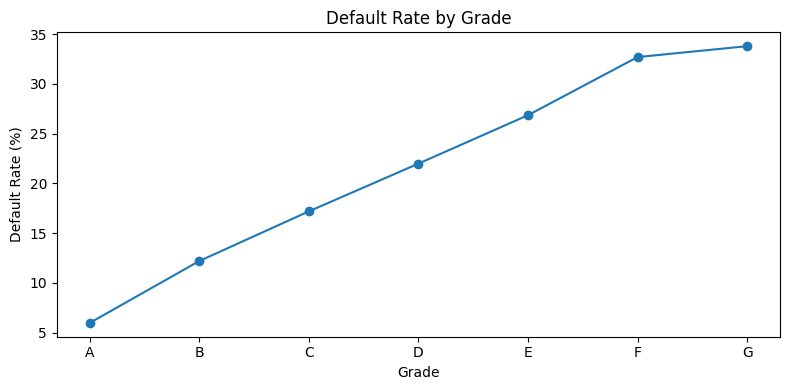

In [53]:
# Calculate default rate by grade
default_by_grade = (
    loan.groupby("grade")["default_flag"]
    .mean()
    .sort_index()
    .mul(100)
)

plt.figure(figsize=(8, 4))
plt.plot(default_by_grade.index, default_by_grade.values, marker="o")
plt.title("Default Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.show()

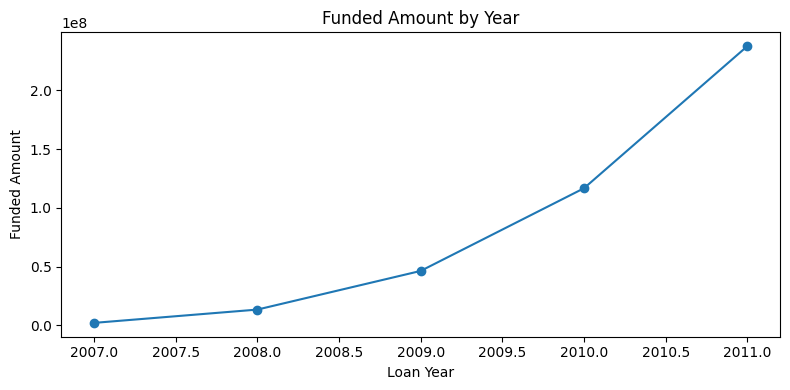

In [54]:
# Aggregate funded amount by issue year
funded_by_year = loan.groupby("loan_year")["funded_amnt"].sum()

plt.figure(figsize=(8, 4))
plt.plot(funded_by_year.index, funded_by_year.values, marker="o")
plt.title("Funded Amount by Year")
plt.xlabel("Loan Year")
plt.ylabel("Funded Amount")
plt.tight_layout()
plt.show()

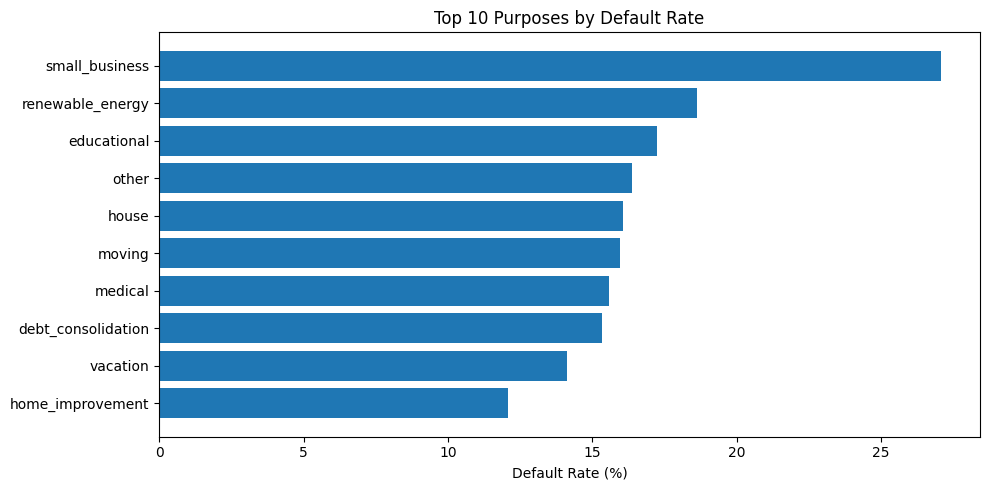

In [55]:
# Show the highest-risk loan purposes
default_by_purpose = (
    loan.groupby("purpose")["default_flag"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .mul(100)
)

plt.figure(figsize=(10, 5))
plt.barh(default_by_purpose.index[::-1], default_by_purpose.values[::-1])
plt.title("Top 10 Purposes by Default Rate")
plt.xlabel("Default Rate (%)")
plt.tight_layout()
plt.show()

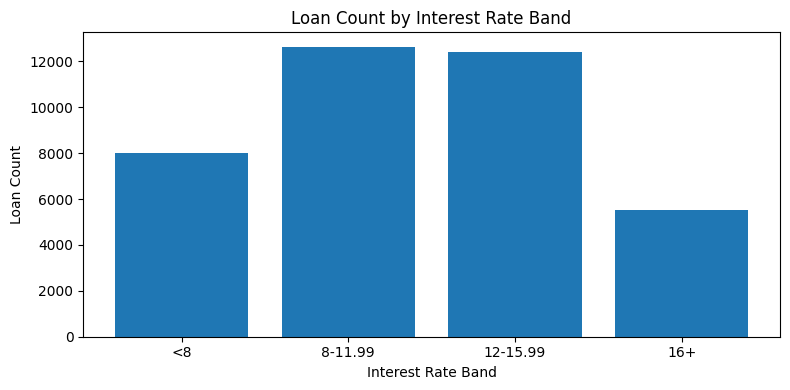

In [56]:
# Count loans across interest rate bands
loan_count_by_rate_band = (
    loan["int_rate_band"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(loan_count_by_rate_band.index.astype(str), loan_count_by_rate_band.values)
plt.title("Loan Count by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Loan Count")
plt.tight_layout()
plt.show()

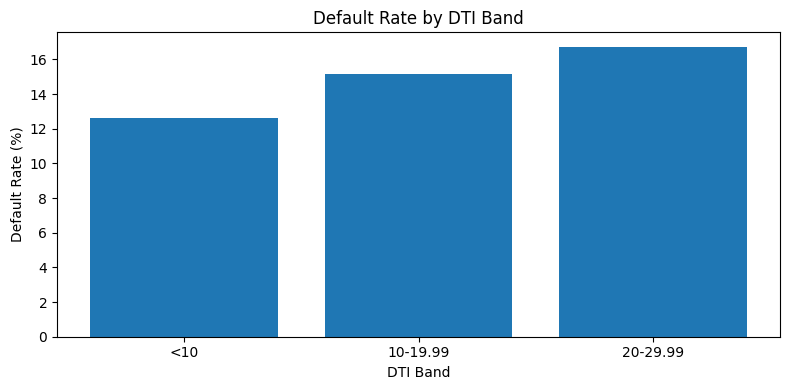

In [57]:
# Compare default rate across DTI bands
default_by_dti = (
    loan.groupby("dti_band")["default_flag"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 4))
plt.bar(default_by_dti.index.astype(str), default_by_dti.values)
plt.title("Default Rate by DTI Band")
plt.xlabel("DTI Band")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.show()

In [58]:
# Build state-level summary table
state_default = (
    loan.groupby("addr_state", as_index=False)
    .agg(
        total_loans=("default_flag", "size"),
        default_rate=("default_flag", "mean"),
        funded_amount=("funded_amnt", "sum")
    )
)

# Convert to percentage for easier interpretation
state_default["default_rate_pct"] = state_default["default_rate"] * 100

state_default.head()

,addr_state,total_loans,default_rate,funded_amount,default_rate_pct
0,AK,78,0.192308,960950,19.230769
1,AL,435,0.124138,4653050,12.413793
2,AR,235,0.114894,2363400,11.489362
3,AZ,849,0.144876,8864600,14.487633
4,CA,6949,0.161894,76026250,16.189380


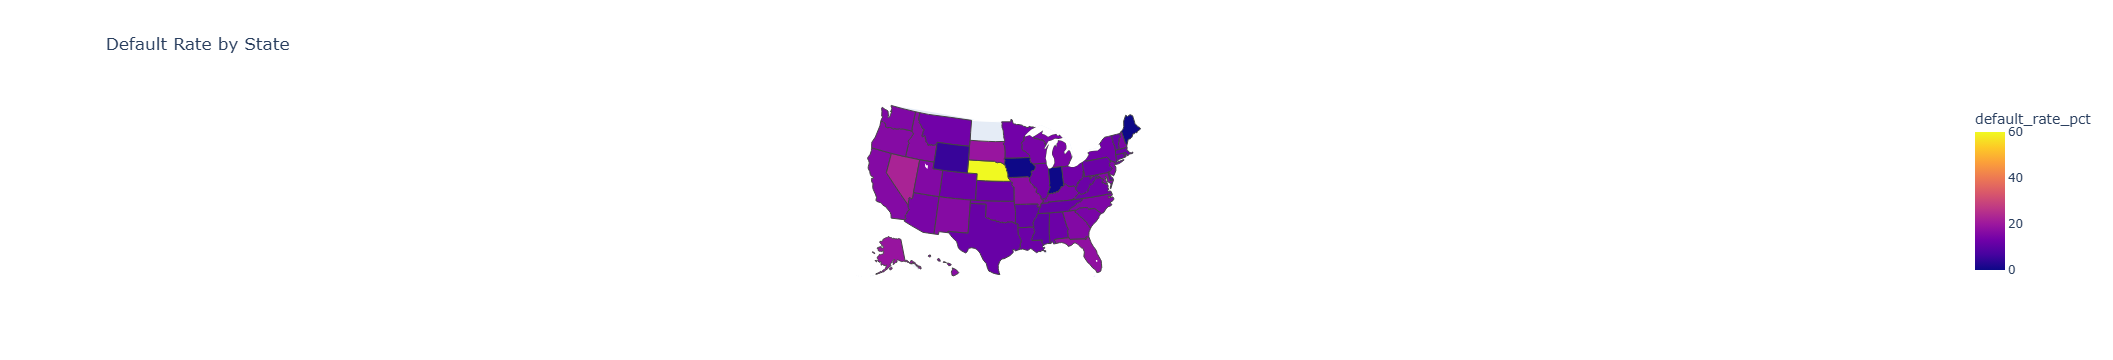

In [59]:
# Create a choropleth map of default rates by state
fig = px.choropleth(
    state_default,
    locations="addr_state",
    locationmode="USA-states",
    color="default_rate_pct",
    scope="usa",
    hover_name="addr_state",
    hover_data={
        "total_loans": True,
        "funded_amount": ":,.0f",
        "default_rate_pct": ":.2f"
    },
    title="Default Rate by State"
)

fig.show()

In [60]:
# Final preview of the cleaned analytical dataset
loan.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,total_rec_prncp,total_rec_int,recoveries,last_pymnt_amnt,default_flag,loan_year,loan_month,loan_month_name,int_rate_band,dti_band
0,5000,5000,36.0,10.65,162.87,B,B2,10+ years,RENT,24000.0,...,5000.00,863.16,0.00,171.62,0,2011,12,December,8-11.99,20-29.99
1,2500,2500,60.0,15.27,59.83,C,C4,< 1 year,RENT,30000.0,...,456.46,435.17,117.08,119.66,1,2011,12,December,12-15.99,<10
2,2400,2400,36.0,15.96,84.33,C,C5,10+ years,RENT,12252.0,...,2400.00,605.67,0.00,649.91,0,2011,12,December,12-15.99,<10
3,10000,10000,36.0,13.49,339.31,C,C1,10+ years,RENT,49200.0,...,10000.00,2214.92,0.00,357.48,0,2011,12,December,12-15.99,20-29.99
5,5000,5000,36.0,7.90,156.46,A,A4,3 years,RENT,36000.0,...,5000.00,632.21,0.00,161.03,0,2011,12,December,<8,10-19.99


In [61]:
loan.to_csv("data/loan_cleaned.csv", index=False)